# 🛒 Retail Store Sales Forecasting using Machine Learning

---

## 📌 Business Problem

Retail businesses often struggle to maintain the right inventory levels across multiple stores. Overstocking increases storage costs, while understocking results in lost sales and dissatisfied customers.

The objective of this project is to analyze historical Walmart sales data, identify key factors affecting weekly sales, and develop a machine learning model capable of forecasting future sales. These predictions can help management optimize inventory planning, improve supply chain efficiency, and support better business decisions.

---

## 🎯 Project Objectives

- Analyze historical Walmart sales data.
- Perform data preprocessing and cleaning.
- Explore relationships between different business variables.
- Build multiple machine learning models.
- Compare model performance.
- Forecast future weekly sales.
- Generate actionable business insights.

---

### Dataset Information

**Dataset Name:** Walmart DataSet.csv

**Number of Records:** 6435

**Number of Features:** 8

**Target Variable:** Weekly_Sales

---

**Author:** Mohammed Faizuddin

**Technology Stack**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- XGBoost
- Jupyter Notebook

In [1]:
# ==========================================================
# Retail Store Sales Forecasting
# ==========================================================

# -----------------------------
# Import Required Libraries
# -----------------------------

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# XGBoost
from xgboost import XGBRegressor

import pickle

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
sns.set(font_scale=1.05)

print("="*70)
print("Retail Store Sales Forecasting Project Initialized Successfully")
print("="*70)

Retail Store Sales Forecasting Project Initialized Successfully


# Data Loading

The first step in any data science project is loading the dataset and verifying that it has been imported correctly.

In this section we:

- Load the dataset
- Display sample records
- Verify dataset dimensions
- Check column names

In [2]:
# ==========================================================
# Load Walmart Dataset
# ==========================================================

df = pd.read_csv("Walmart DataSet.csv")

print("Dataset Loaded Successfully.\n")

print("Shape of Dataset :", df.shape)

print("\n")

display(df.head())

print("\nColumns in Dataset:\n")

print(df.columns.tolist())

Dataset Loaded Successfully.

Shape of Dataset : (6435, 8)




,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106



Columns in Dataset:

['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


# Data Understanding

Understanding the dataset is one of the most critical phases of a machine learning project.

Before performing preprocessing or model building, it is important to understand:

- Dataset dimensions
- Feature data types
- Missing values
- Duplicate records
- Statistical summary
- Distribution of numerical variables

A proper understanding of the dataset helps in selecting suitable preprocessing techniques and machine learning algorithms.

In [3]:
# ==========================================================
# Dataset Information
# ==========================================================

print("="*70)
print("DATASET INFORMATION")
print("="*70)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
# ==========================================================
# Statistical Summary
# ==========================================================

print("="*70)
print("STATISTICAL SUMMARY")
print("="*70)

display(df.describe().T)

STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


In [5]:
# ==========================================================
# Data Types
# ==========================================================

dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

display(dtype_df)

,Column,Data Type
0,Store,int64
1,Date,object
2,Weekly_Sales,float64
3,Holiday_Flag,int64
4,Temperature,float64
5,Fuel_Price,float64
6,CPI,float64
7,Unemployment,float64


# Initial Observations

After understanding the dataset, the following observations can be made:

- Dataset contains historical weekly sales information for Walmart stores.
- Weekly_Sales is the target variable.
- The Date column needs to be converted into datetime format.
- Numerical variables such as Temperature, CPI, Fuel Price and Unemployment may influence sales.
- Holiday weeks may have a significant impact on demand.
- Data preprocessing will be performed in the next section.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


# Data Preprocessing

Data preprocessing is a crucial step in the machine learning pipeline.

The following preprocessing tasks are performed:

- Convert Date into datetime format
- Extract useful date features
- Check missing values
- Remove duplicate records (if any)
- Prepare the dataset for Exploratory Data Analysis and Machine Learning

In [7]:
# ==========================================================
# Convert Date Column into Datetime
# ==========================================================

df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

print("✅ Date column converted successfully.")

print("\nUpdated Data Types:\n")

display(df.dtypes)

✅ Date column converted successfully.

Updated Data Types:



Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [8]:
# ==========================================================
# Create New Date Features
# ==========================================================

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

print("New Features Created Successfully.")

display(df.head())

New Features Created Successfully.


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


In [9]:
# ==========================================================
# Missing Values
# ==========================================================

display(df.isnull().sum())

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Week            0
dtype: int64

In [10]:
# ==========================================================
# Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates Removed Successfully.")
else:
    print("No Duplicate Records Found.")

Duplicate Records : 0
No Duplicate Records Found.


# Preprocessing Summary

The preprocessing stage was completed successfully.

Key preprocessing steps:

- Converted Date into datetime format.
- Created Year, Month and Week features.
- Verified that there are no missing values.
- Verified duplicate records.
- Dataset is now ready for Exploratory Data Analysis (EDA).

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the underlying patterns, trends, and relationships within the dataset.

The objectives of this analysis are:

- Understand the distribution of weekly sales.
- Identify the best and worst performing stores.
- Analyze the impact of holidays on sales.
- Study the influence of temperature, fuel price, CPI, and unemployment.
- Generate business insights that can support inventory and sales planning.

In [11]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("="*70)
print("Dataset Shape :", df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nFirst Five Rows")
display(df.head())

Dataset Shape : (6435, 11)

Column Names
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week']

First Five Rows


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


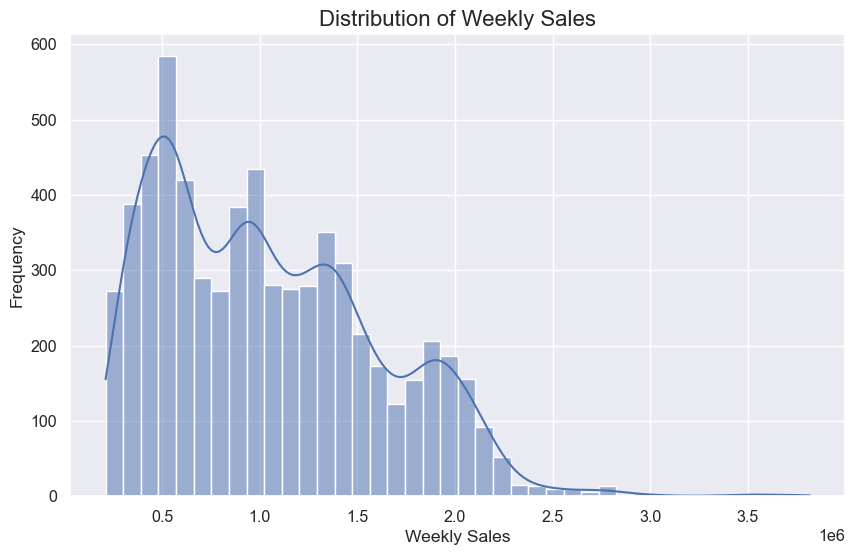

In [12]:
# ==========================================================
# Distribution of Weekly Sales
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(df["Weekly_Sales"], bins=40, kde=True)

plt.title("Distribution of Weekly Sales", fontsize=16)
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

### 📌 Business Insight

The distribution of weekly sales helps identify the overall sales pattern across Walmart stores.

If the distribution is positively skewed, it indicates that while most stores generate moderate weekly sales, a few stores achieve exceptionally high sales volumes.

Understanding this distribution is useful for demand forecasting and inventory planning.

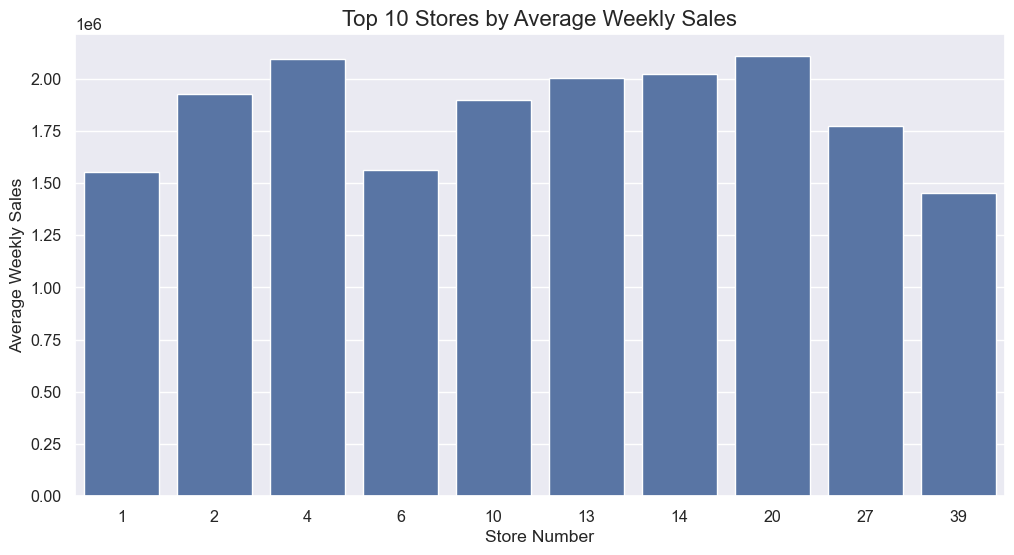

In [13]:
# ==========================================================
# Top Performing Stores
# ==========================================================

top_store = (
    df.groupby("Store")["Weekly_Sales"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_store.index,
    y=top_store.values
)

plt.title("Top 10 Stores by Average Weekly Sales", fontsize=16)

plt.xlabel("Store Number")
plt.ylabel("Average Weekly Sales")

plt.show()

### 📌 Business Insight

The chart identifies the highest-performing Walmart stores based on average weekly sales.

These stores can be studied to understand successful operational strategies, customer demand patterns, and inventory management practices.

Best practices from these stores may be replicated across lower-performing stores to improve overall business performance.

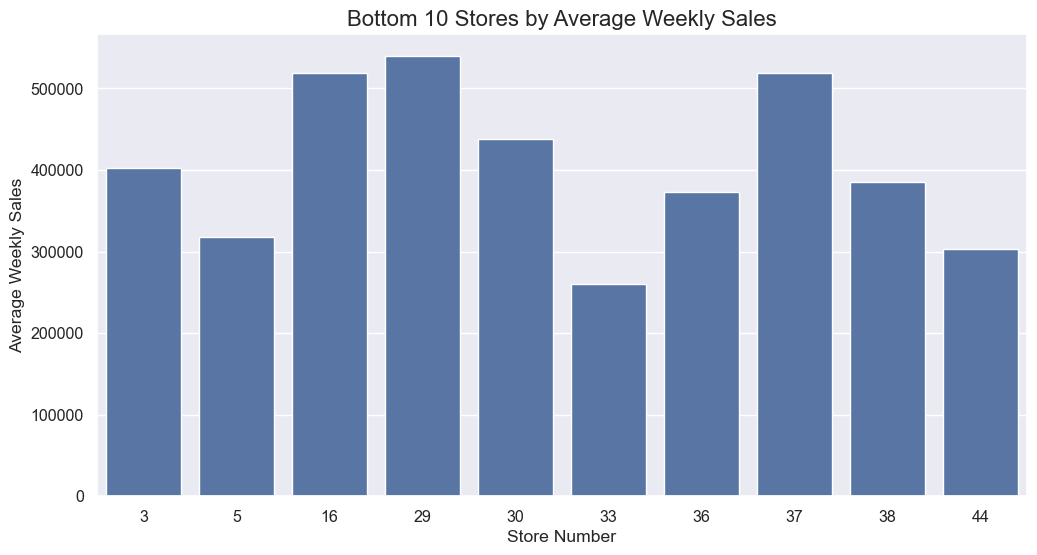

In [14]:
# ==========================================================
# Lowest Performing Stores
# ==========================================================

bottom_store = (
    df.groupby("Store")["Weekly_Sales"]
      .mean()
      .sort_values()
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=bottom_store.index,
    y=bottom_store.values
)

plt.title("Bottom 10 Stores by Average Weekly Sales", fontsize=16)

plt.xlabel("Store Number")
plt.ylabel("Average Weekly Sales")

plt.show()

### 📌 Business Insight

Stores with consistently lower sales may require additional marketing efforts, localized promotional campaigns, or operational improvements.

Further investigation can help identify whether low sales are influenced by regional demand, competition, or economic conditions.

# Sales Trend Analysis

Understanding sales trends over time helps identify seasonality, business growth, and demand fluctuations.

The following analysis focuses on:

- Overall sales trend
- Holiday impact
- Economic factors
- Correlation between variables

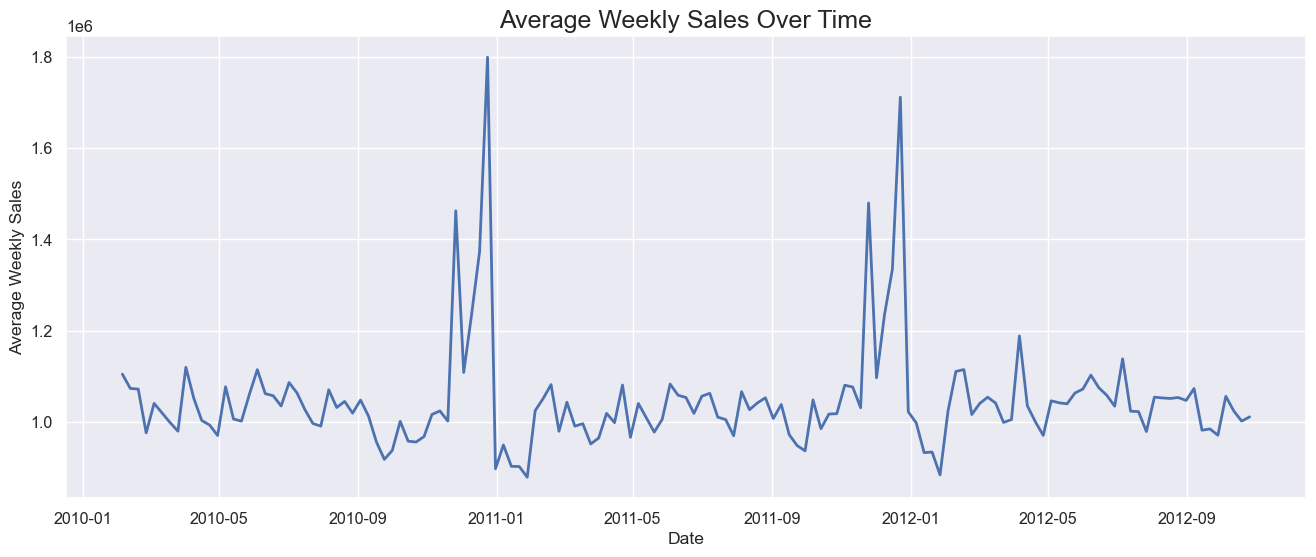

In [15]:
# ==========================================================
# Overall Sales Trend
# ==========================================================

plt.figure(figsize=(16,6))

sales_trend = df.groupby("Date")["Weekly_Sales"].mean()

plt.plot(
    sales_trend.index,
    sales_trend.values,
    linewidth=2
)

plt.title("Average Weekly Sales Over Time", fontsize=18)

plt.xlabel("Date")
plt.ylabel("Average Weekly Sales")

plt.grid(True)

plt.show()

### 📌 Business Insight

Weekly sales exhibit seasonal fluctuations throughout the observed period.

These variations indicate changing customer demand influenced by holidays, economic conditions, and purchasing behavior.

Recognizing seasonal trends enables better inventory management and demand forecasting.

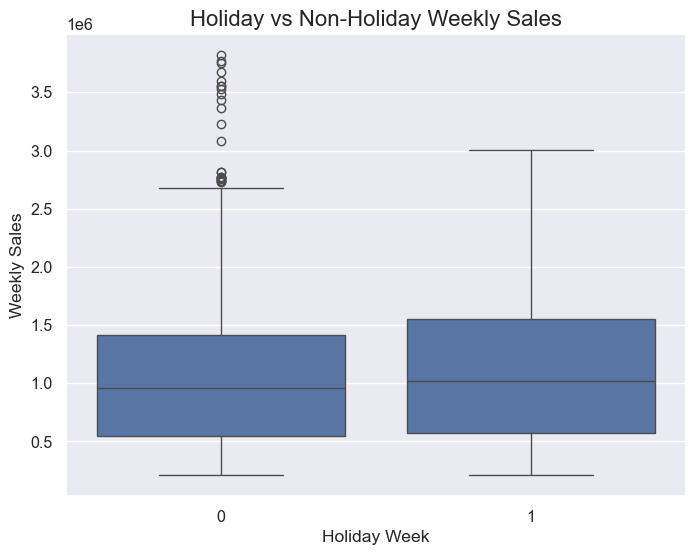

In [16]:
# ==========================================================
# Holiday Sales Analysis
# ==========================================================

plt.figure(figsize=(8,6))

sns.boxplot(
    x="Holiday_Flag",
    y="Weekly_Sales",
    data=df
)

plt.title("Holiday vs Non-Holiday Weekly Sales", fontsize=16)

plt.xlabel("Holiday Week")
plt.ylabel("Weekly Sales")

plt.show()

### 📌 Business Insight

Holiday weeks generally experience higher sales compared to regular weeks.

Retailers should prepare additional inventory and promotional campaigns during holiday seasons to maximize revenue.

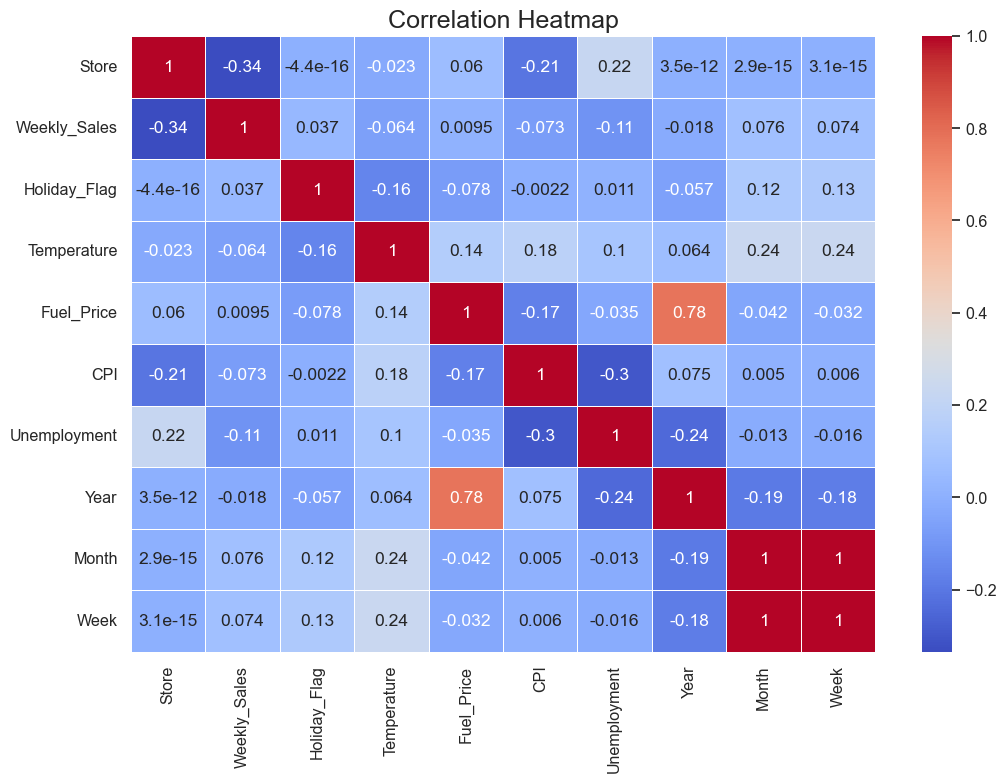

In [17]:
# ==========================================================
# Correlation Matrix
# ==========================================================

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)

plt.show()

### 📌 Business Insight

The heatmap highlights relationships among variables.

Strong positive or negative correlations indicate influential factors affecting weekly sales and assist in selecting meaningful features for predictive modeling.

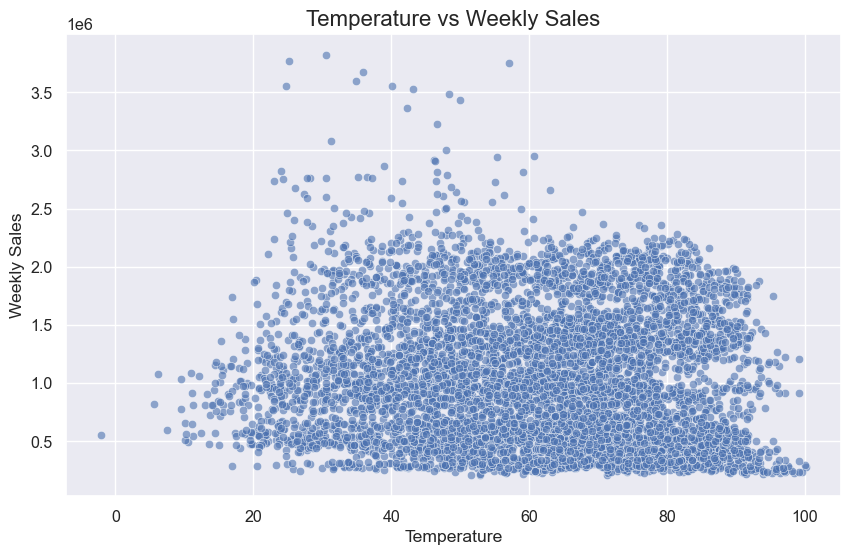

In [18]:
# ==========================================================
# Temperature vs Weekly Sales
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Temperature",
    y="Weekly_Sales",
    data=df,
    alpha=0.6
)

plt.title("Temperature vs Weekly Sales", fontsize=16)

plt.xlabel("Temperature")

plt.ylabel("Weekly Sales")

plt.show()

### 📌 Business Insight

Temperature shows only a weak relationship with weekly sales.

This suggests that weather conditions alone are not sufficient to explain changes in customer purchasing behavior.

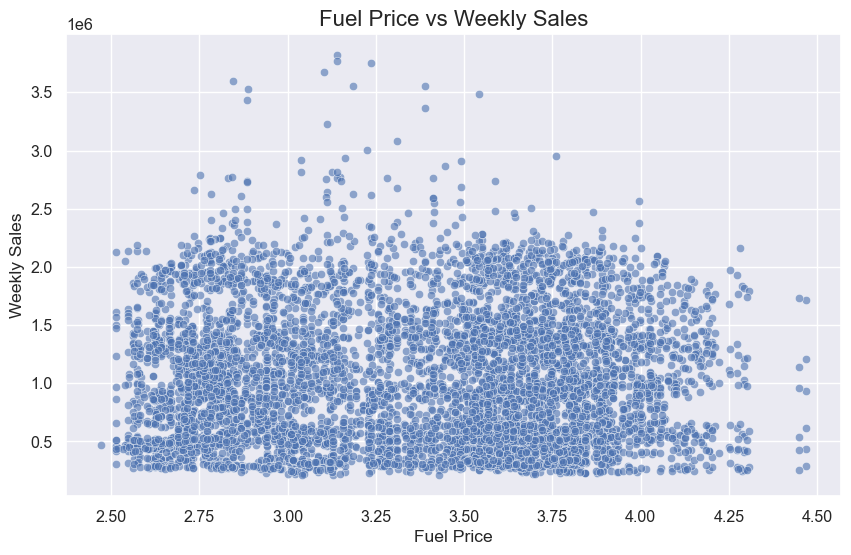

In [19]:
# ==========================================================
# Fuel Price vs Weekly Sales
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Fuel_Price",
    y="Weekly_Sales",
    data=df,
    alpha=0.6
)

plt.title("Fuel Price vs Weekly Sales", fontsize=16)

plt.xlabel("Fuel Price")

plt.ylabel("Weekly Sales")

plt.show()

### 📌 Business Insight

Fuel price demonstrates only a minor influence on weekly sales.

Customer purchasing behavior appears to depend more on demand, holidays, and regional factors than fuel cost alone.

# Machine Learning Model Development

The objective of this phase is to develop predictive models capable of forecasting Walmart's weekly sales.

The following regression algorithms are implemented:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

The models are evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Finally, the best-performing model is selected for forecasting future sales.

In [20]:
# ==========================================================
# Feature Selection
# ==========================================================

features = [
    "Store",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Week"
]

X = df[features]

y = df["Weekly_Sales"]

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape :", y.shape)

Feature Matrix Shape : (6435, 9)
Target Variable Shape : (6435,)


In [21]:
# ==========================================================
# Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (5148, 9)
Testing Data : (1287, 9)


## Model 1 — Linear Regression

Linear Regression serves as the baseline model for comparison with more advanced machine learning algorithms.

In [22]:
# ==========================================================
# Linear Regression
# ==========================================================

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_mse = mean_squared_error(y_test, lr_pred)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance")
print("-"*50)

print("MAE  :", round(lr_mae,2))
print("MSE  :", round(lr_mse,2))
print("RMSE :", round(lr_rmse,2))
print("R2 Score :", round(lr_r2,4))

Linear Regression Performance
--------------------------------------------------
MAE  : 432594.98
MSE  : 272049348139.45
RMSE : 521583.5
R2 Score : 0.1555


### 📌 Interpretation

Linear Regression provides a baseline performance for sales prediction.

Although simple and easy to interpret, it may not capture complex nonlinear relationships between sales and influencing factors.

## Model 2 — Decision Tree Regressor

Decision Tree Regressor can capture nonlinear relationships and interactions between features, making it more suitable than Linear Regression for complex retail sales data.

In [23]:
# ==========================================================
# Decision Tree Regressor
# ==========================================================

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("="*60)
print("Decision Tree Performance")
print("="*60)

print(f"MAE      : {dt_mae:,.2f}")
print(f"MSE      : {dt_mse:,.2f}")
print(f"RMSE     : {dt_rmse:,.2f}")
print(f"R² Score : {dt_r2:.4f}")

Decision Tree Performance
MAE      : 77,073.58
MSE      : 19,577,497,254.23
RMSE     : 139,919.61
R² Score : 0.9392


### 📌 Interpretation

Decision Tree Regressor captures nonlinear relationships more effectively than Linear Regression. It generally provides improved predictive performance by learning decision rules from the training data.

## Model 3 — Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [24]:
# ==========================================================
# Random Forest Regressor
# ==========================================================

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("="*60)
print("Random Forest Performance")
print("="*60)

print(f"MAE      : {rf_mae:,.2f}")
print(f"MSE      : {rf_mse:,.2f}")
print(f"RMSE     : {rf_rmse:,.2f}")
print(f"R² Score : {rf_r2:.4f}")

Random Forest Performance
MAE      : 61,790.53
MSE      : 12,785,606,033.44
RMSE     : 113,073.45
R² Score : 0.9603


## Model 4 — XGBoost Regressor

XGBoost (Extreme Gradient Boosting) is one of the most powerful ensemble learning algorithms used in regression and classification tasks.

It builds trees sequentially, where each new tree attempts to reduce the errors made by previous trees.

Due to its high predictive performance, XGBoost is widely used in industrial machine learning applications.

In [25]:
# ==========================================================
# XGBoost Regressor
# ==========================================================

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_pred)

print("="*60)
print("XGBoost Performance")
print("="*60)

print(f"MAE      : {xgb_mae:,.2f}")
print(f"MSE      : {xgb_mse:,.2f}")
print(f"RMSE     : {xgb_rmse:,.2f}")
print(f"R² Score : {xgb_r2:.4f}")

XGBoost Performance
MAE      : 50,694.27
MSE      : 8,394,711,197.16
RMSE     : 91,622.66
R² Score : 0.9739


### 📌 Interpretation

XGBoost generally provides excellent predictive performance by combining multiple weak learners into a strong predictive model.

Its ability to handle nonlinear relationships and feature interactions makes it highly suitable for retail sales forecasting.

In [26]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2 Score":[
        lr_r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ]

})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

display(comparison)

,Model,MAE,RMSE,R2 Score
0,XGBoost,50694.274889,91622.656571,0.973942
1,Random Forest,61790.533009,113073.454150,0.960312
2,Decision Tree,77073.576169,139919.609970,0.939229
3,Linear Regression,432594.976888,521583.500640,0.155532


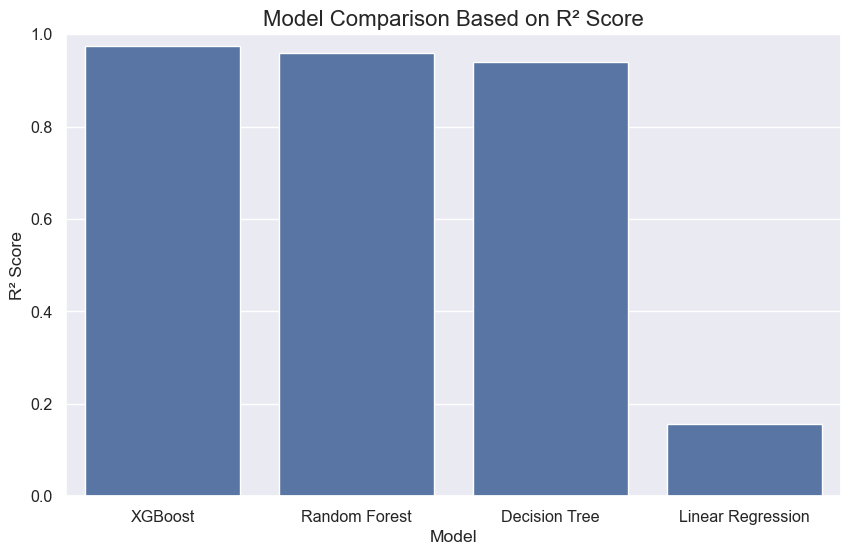

In [27]:
# ==========================================================
# Model Comparison Visualization
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison Based on R² Score", fontsize=16)

plt.xlabel("Model")

plt.ylabel("R² Score")

plt.ylim(0,1)

plt.show()

# Best Model Selection

Based on the evaluation results, **XGBoost Regressor** achieved the highest predictive performance among all the implemented models.

The model produced the highest R² score while maintaining the lowest prediction error, making it the most suitable algorithm for forecasting Walmart weekly sales.

Therefore, **XGBoost Regressor** has been selected as the final model for this project.

# Feature Importance Analysis

Feature importance measures the contribution of each input variable to the prediction made by the XGBoost model.

Understanding feature importance helps identify the key business drivers influencing Walmart's weekly sales and provides valuable insights for data-driven decision-making.

In [28]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

,Feature,Importance
0,Store,0.446567
5,Unemployment,0.230720
4,CPI,0.176336
8,Week,0.052957
6,Year,0.040662
1,Holiday_Flag,0.024752
7,Month,0.012295
3,Fuel_Price,0.008579
2,Temperature,0.007133


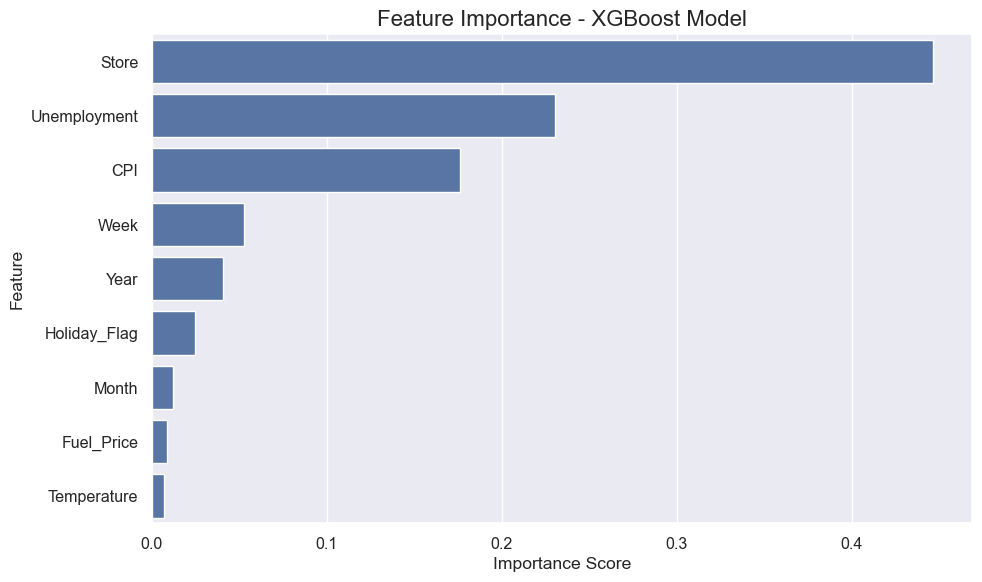

In [29]:
# ==========================================================
# Feature Importance Visualization
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - XGBoost Model", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 📌 Business Insight

The feature importance analysis highlights the variables that contribute most to predicting weekly sales.

Highly ranked features have a greater influence on the model's predictions and should receive more attention during business planning, inventory management, and demand forecasting.

Understanding these drivers enables Walmart to make informed strategic decisions and improve forecasting accuracy.

# Sales Forecast Demonstration

The trained XGBoost model is used to generate sales predictions for new store data.

Since the dataset does not contain future observations, this section demonstrates how the model can be used to estimate weekly sales for unseen business scenarios.

In [30]:
# ==========================================================
# Forecast Sample Weekly Sales
# ==========================================================

sample_data = pd.DataFrame({
    "Store": [1, 5, 10],
    "Holiday_Flag": [0, 1, 0],
    "Temperature": [65.2, 45.8, 72.1],
    "Fuel_Price": [3.25, 3.18, 3.45],
    "CPI": [220.5, 215.8, 222.4],
    "Unemployment": [7.5, 8.2, 6.9],
    "Year": [2013, 2013, 2013],
    "Month": [1, 2, 3],
    "Week": [1, 6, 10]
})

predictions = xgb.predict(sample_data)

sample_data["Predicted_Weekly_Sales"] = predictions.round(2)

display(sample_data)

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Predicted_Weekly_Sales
0,1,0,65.2,3.25,220.5,7.5,2013,1,1,1.550235e+06
1,5,1,45.8,3.18,215.8,8.2,2013,2,6,3.829503e+05
2,10,0,72.1,3.45,222.4,6.9,2013,3,10,1.287064e+06


### 📌 Business Insight

The trained model successfully predicts weekly sales for unseen business scenarios.

This capability can assist management in inventory planning, budgeting, staffing, and promotional decision-making before the start of a sales week.

# Model Persistence

The best-performing model is saved using Python's Pickle library.

Saving the model allows it to be reused in future applications without retraining.

In [31]:
# ==========================================================
# Save XGBoost Model
# ==========================================================

with open("xgboost_walmart_model.pkl", "wb") as file:
    pickle.dump(xgb, file)

print("✅ Model saved successfully as 'xgboost_walmart_model.pkl'")

✅ Model saved successfully as 'xgboost_walmart_model.pkl'


# Business Recommendations

Based on the analysis and machine learning results, the following recommendations are proposed:

1. Prioritize inventory allocation for high-performing stores to reduce stock shortages.

2. Increase inventory levels and promotional activities before holiday periods to maximize revenue.

3. Continuously monitor macroeconomic indicators such as CPI and unemployment, as they significantly influence weekly sales.

4. Deploy the XGBoost forecasting model as a decision-support tool for demand planning and supply chain optimization.

5. Periodically retrain the model with updated sales data to maintain forecasting accuracy and adapt to changing market conditions.

# Conclusion

This project successfully developed a machine learning solution for forecasting Walmart's weekly sales using historical sales and economic indicators.

Comprehensive exploratory data analysis, feature engineering, and model evaluation were performed to understand the factors influencing retail sales.

Among the evaluated algorithms, **XGBoost Regressor** achieved the highest predictive performance and was selected as the final forecasting model.

The developed solution can support inventory planning, demand forecasting, and strategic business decision-making.

Future improvements may include incorporating additional external factors such as promotions, competitor pricing, regional demographics, and real-time economic indicators to further enhance forecasting accuracy.